# Assignment 1 (Using CICIDS2017 network intrusion detection dataset)

## 1. The Group 
#### Group 22
Members: Jenna Kiviaho, Lotta Kauppinen, Marjaana Koski, Jani Laakso, Aleksi Savukoski

---

## 2. Contributions for the group members

| Group member name | Contibution |
| :--- | :--- |
| Aleksi Savukoski | kNN training and testing (PCA, SMOTE, k, MinMax Scaler), creating the base of the skeleton |
| Lotta Kauppinen | Studied the SVMs and performed testing with only the baseline, PCA, SMOTE and PCA + SMOTE. Based on the results created Scaler comparison between StandardScaler vs MinMaxScaler. Small changes to the skeleton, because of errors that occured in the training stage. Studying the Naive Bayes and creating the code.|
| Jenna Kiviaho | Code for splitting 60/20/20 and Logistic Regression with multiple models |
| Marjaana Koski | Creating the sample dataset with 100 000 rows. Complete defining, determination, and planning of decision tree models. Writing of short theories behind each pipeline parameter. |
| Jani Laakso | Random Forest |




---

---

## 3. Use of AI

| Group member name | Contibution |
| :--- | :--- |
| Aleksi Savukoski | Claude helps with code and explains step by step how and why the code works. |
| Lotta Kauppinen | Sparred with AI on how to make the code perform faster. Some of the suggestions worked and some of them not. AI helped to translate my thoughts of the results in to english. |
| Marjaana Koski | Claude used in hyperparameter fine tuning of decision tree models. AI was used to support comprehension and outlining of the assignment. |

---

## 4. Dataset, Splitting the dataset

In [ ]:
# Basic libraries:

import numpy as np
import pandas as pd
import sklearn
import imblearn
import xgboost
import matplotlib
import seaborn
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split

---

In [2]:
df_original = pd.read_csv("data/cicids2017_cleaned.csv", low_memory=False) # Remember to put the correct csv-file to the data-folder
df_100 = df_original.sample(n=100_000, random_state=42)

In [3]:
# Comparing the sample dataset to the original one

counts_original = df_original["Attack Type"].value_counts()
percentages_original = df_original["Attack Type"].value_counts(normalize=True)

counts_100 = df_100["Attack Type"].value_counts()
percentages_100 = df_100["Attack Type"].value_counts(normalize=True)

comparison = pd.DataFrame({
    "Row count original" : counts_original, 
    "Count-% original": percentages_original.round(5)*100,
    "Row count sample file" : counts_100, 
    "Count-% sample file": percentages_100.round(5)*100})

print(comparison)

                Row count original  Count-% original  Row count sample file  \
Attack Type                                                                   
Normal Traffic             2095057            83.112                  83081   
DoS                         193745             7.686                   7673   
DDoS                        128014             5.078                   5115   
Port Scanning                90694             3.598                   3574   
Brute Force                   9150             0.363                    377   
Web Attacks                   2143             0.085                     92   
Bots                          1948             0.077                     88   

                Count-% sample file  
Attack Type                          
Normal Traffic               83.081  
DoS                           7.673  
DDoS                          5.115  
Port Scanning                 3.574  
Brute Force                   0.377  
Web Attacks           

In [4]:
df_100.to_csv("cleaned_100k.csv", index=False)

In [5]:
# The dataset and dataframe to be used

df = pd.read_csv("cleaned_100k.csv", low_memory=False)

The original dataset contained over 2.3 million rows. The original CSV file was sampled with Pandas to 100 000 items with random state of 42. If the original dataframe based on cicids2017_cleaned.csv would be read in, with random state = 42 the sample dataframe would be exactly the same.

 In dataset cicids2017_cleaned.csv there are 7 unique attack types, it is a paramount to have each type represented in the sample file. This way only the train-test model can learn about more rare attack type classes. For performance and computational purposes, randomly chosen 100 000 rows from the original set were chosen.

The comparison between original dataset and sample file is represented in this table:
| Attack Type     | Row Count (Original) | Percent % (Original) | Row Count (Sample) | Percent % (Sample) |
|-----------------|-----------------------|------------------------|---------------------|----------------------|
| Normal Traffic  | 2 095 057             | 83.112                 | 83 081              | 83.081               |
| DoS             |   193 745             | 7.686                  | 7 673               | 7.673                |
| DDoS            |   128 014             | 5.078                  | 5 115               | 5.115                |
| Port Scanning   |    90 694             | 3.598                  | 3 574               | 3.574                |
| Brute Force     |     9 150             | 0.363                  |   377               | 0.377                |
| Web Attacks     |     2 143             | 0.085                  |    92               | 0.092                |
| Bots            |     1 948             | 0.077                  |    88               | 0.088                |

The percentages of each attack type are well represented in the dataset, as it mimics the original dataset's propotions.

The dataframe was exported into CSV file named cleaned_100k.csv. This CSV is also used as a basis for the assignment's dataframe, which confirms, that the assignment is based solely on the sampled dataset and dataframe.

In [6]:
# Defining target
y = df['Attack Type']
X = df.drop('Attack Type', axis = 1)

# First to split data into train and test
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

# Split train again into train and validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify = y_train_val)


print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(60000, 52)
(20000, 52)
(20000, 52)


---

### Shared skeleton for the group

The cell below is a **shared skeleton** every group member uses as the starting point for their own classifier. It locks down the decisions that must be identical across the team so results are comparable in Section 10:

- the same 10 features (`FEATURES`),
- the same pipeline order (Scaler → PCA → SMOTE → Classifier),
- the same scoring metric for GridSearchCV (`f1_macro`, because accuracy is misleading under 83% class imbalance),
- the same `run_experiment()` helper so every algorithm is evaluated the same way and logged into `all_results`.

Each member only fills in their classifier and its `param_grid`; an example for kNN is shown at the bottom of the cell (commented out).

Note: SMOTE is wrapped by **imblearn's** Pipeline, not sklearn's, so synthetic samples are only generated inside each CV training fold, never inside the fold used for scoring. Using sklearn's Pipeline here would silently inflate scores.

In [ ]:
# =====================================================================
#  SHARED SKELETON - all group members use this as the starting point.
#  Only the classifier in 'clf' and the 'param_grid' change per algorithm.
# =====================================================================

# Extra imports beyond the ones in the top imports cell
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


# Agreed 10-feature list
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False, use_poly=False):

    steps = []

    # 1. Scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))
    # 2. Polynomial features
    if use_poly:
        steps.append(("poly", PolynomialFeatures(degree=2))) # 29.4. added for polynomial features testing

    # 3. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))

    # 4.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 4.2 OR, use PCA
    if use_pca:
        steps.append(("pca", PCA()))

    # 5. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []


# =====================================================================
#  PER-MEMBER USAGE EXAMPLE (kNN - commented out)
#  Copy this block, swap in your own classifier + param_grid.
# =====================================================================
# from sklearn.neighbors import KNeighborsClassifier
#
# knn_grid = {
#     "pca__n_components": [4, 6, 8],
#     "clf__n_neighbors":  [3, 5, 7, 11],
#     "clf__weights":      ["uniform", "distance"],
# }
#
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN + SMOTE + PCA")
# )
# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN no-SMOTE baseline", use_smote=False)
# )

Fitting 3 folds for each of 4 candidates, totalling 12 fits


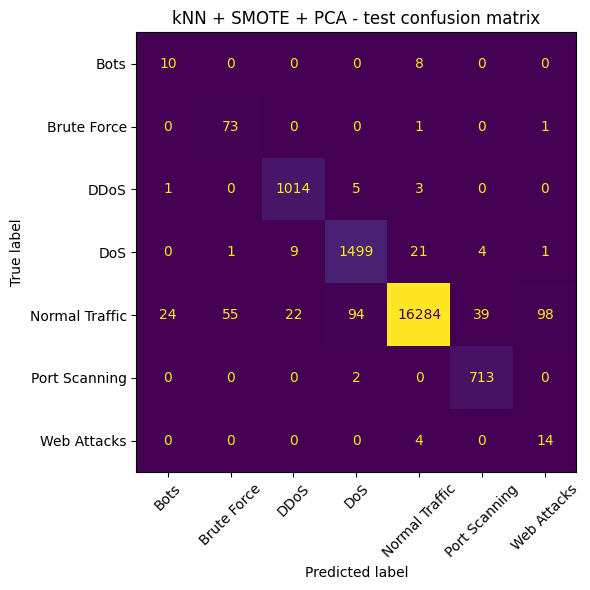


=== kNN + SMOTE + PCA ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9801  f1_macro=0.7569
Test acc=0.9804  f1_macro=0.7429
                precision    recall  f1-score   support

          Bots      0.286     0.556     0.377        18
   Brute Force      0.566     0.973     0.716        75
          DDoS      0.970     0.991     0.981      1023
           DoS      0.937     0.977     0.956      1535
Normal Traffic      0.998     0.980     0.989     16616
 Port Scanning      0.943     0.997     0.969       715
   Web Attacks      0.123     0.778     0.212        18

      accuracy                          0.980     20000
     macro avg      0.689     0.893     0.743     20000
  weighted avg      0.987     0.980     0.983     20000



In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid_lite = {
    "pca__n_components": [6, 8],
    "clf__n_neighbors":  [3, 5],
    "clf__weights":      ["distance"],
}

all_results.append(
    run_experiment(KNeighborsClassifier(), knn_grid_lite,
                   label="kNN + SMOTE + PCA")
)

In [9]:
#AS 27.4. Commented out for testing purposes, as the full grid takes a long time to run. The above "lite" version is used instead.
# from sklearn.neighbors import KNeighborsClassifier
#
# knn_grid = {
#     "pca__n_components": [4, 6, 8],
#     "clf__n_neighbors":  [3, 5, 7, 11],
#     "clf__weights":      ["uniform", "distance"],
#}

# all_results.append(
#     run_experiment(KNeighborsClassifier(), knn_grid,
#                    label="kNN + SMOTE + PCA")
#)

## 5. Label variable

This is a **multi-class classification** problem with 7 classes in the `Attack Type` column:

| Class | Share of data |
| :--- | ---: |
| Normal Traffic | 83.08% |
| DoS | 7.67% |
| DDoS | 5.12% |
| Port Scanning | 3.57% |
| Brute Force | 0.38% |
| Web Attacks | 0.09% |
| Bots | 0.09% |

The dataset is **severely imbalanced** — Normal Traffic outnumbers Bots by roughly 1000:1. Because of this, we report **`f1_macro`** as our primary metric rather than raw accuracy. Accuracy is misleading here: a model that predicts "Normal Traffic" for every single row would still score ~83% accuracy while completely failing at its actual job (detecting attacks). `f1_macro` averages the F1-score across all 7 classes equally, so a model has to do well on the rare attack types to earn a good score.

For the same reason we apply **SMOTE** inside the training pipeline to synthetically oversample the minority classes during fitting (§7), and we use **`stratify=y`** when splitting so that every class is present in the train, validation, and test sets in the same proportions.

---

## 6. Feature variables

The cleaned dataset contains 52 numeric feature columns. Rather than feed all of them to every model, the group agreed on a common set of **10 flow-level features** chosen to cover the main information axes a network-traffic classifier needs. Using the same 10 features across all 7 algorithms also makes the comparison in §10 meaningful — any performance differences come from the classifier, not from different feature sets.

**The 10 "agreed" features:**

| Feature | What it captures |
| :--- | :--- |
| Flow Duration | How long the connection lasted |
| Total Fwd Packets | Packet count in the forward direction (volume) |
| Total Length of Fwd Packets | Total bytes in the forward direction (volume) |
| Flow Bytes/s | Byte rate — high for DDoS, low for Port Scanning |
| Flow Packets/s | Packet rate — separates scanning from bulk traffic |
| Fwd Packet Length Mean | Average size of forward packets |
| Bwd Packet Length Mean | Average size of backward packets — asymmetry is a strong attack signal |
| Packet Length Mean | Overall packet size average |
| Packet Length Std | Variability in packet size — uniform sizes suggest automated/attack traffic |
| Average Packet Size | Summary size statistic |

**Reasoning behind the selection:**

1. **Coverage of five information axes.** Network attacks differ along *timing* (Flow Duration), *volume* (packet and byte totals), *rate* (bytes/s, packets/s), *packet size distribution* (means and std), and *directional asymmetry* (forward vs backward statistics). Each axis is represented.
2. **Forward + backward directions.** Many attacks are highly asymmetric — Port Scanning sends lots of small SYN packets forward and receives little back; DoS floods one direction. Keeping both `Fwd` and `Bwd` statistics preserves this signal.
3. **Ratios and rates, not just counts.** Absolute counts depend on how long the flow ran. `Flow Bytes/s` and `Flow Packets/s` are normalized and comparable across flow durations.
4. **Avoid redundant/derived columns.** The full dataset contains many near-duplicate or derived columns (subflow totals, init window sizes for each direction, etc.). Picking a compact set reduces multicollinearity, speeds up training, and — importantly for kNN — mitigates the curse of dimensionality.
5. **Algorithm-neutral features.** All 10 are continuous numeric columns that work directly with scaling, PCA, and SMOTE without special encoding.


---

## 7. SMOTE


As mentioned, the used dataset is highly skewed. This imbalance is tried to improve with a particular focus on the implementation of Synthetic Minority Over-sampling Technique, or SMOTE. By increasing the representation of these rare classes in the training data, SMOTE forces the ML models to learn more about these classes' patterns. As a result, the amount of False Negatives for attack classes is expected decrease.

#### SMOTE and Logistic Regression

Without SMOTE, the model predicted many of the minor classes as Normal Traffic. The recall was at 0% for Bots, Brute Force, Port Scanning and Web Attacks. The overall accuracy was around 0.92 (92%), but the macro F1-score was only 0.375 (35,7%). Without SMOTE the model performed poorly and did not find many of the attacks which makes the model useless.

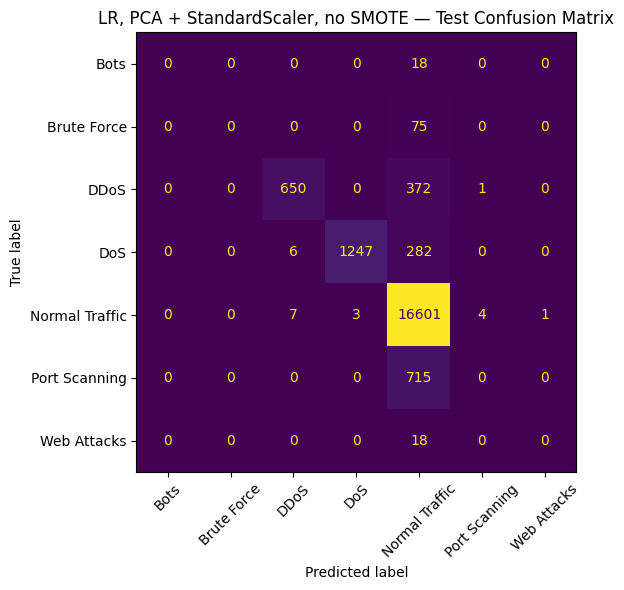

With SMOTE the recall increased tremendously however it labels Normal Traffic as attacks. For information security it is more important to distuingish the actual attacks more accurately even when precision and overall accuracy decreases. The macro f1-score was still low but with SMOTE it increased to 0.438 (43,8%) which makes this model more valuable.

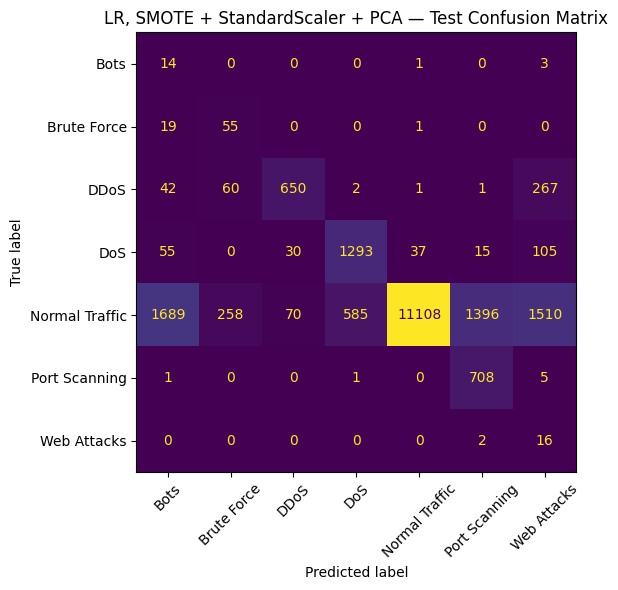

This table will show the statistics without and with SMOTE.

| Model                                      | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| LR + **no SMOTE** + PCA + StandardScaler       |  0.3748 | 0.925    | 0.35        | 0.414       |
| LR + **SMOTE** + PCA + StandardScaler            |  0.4381     |   0.692  | 0.791  | 0.435  |

Next there are the codes what were used to run the model without and with SMOTE.


In [ ]:
# Parameters
lr_params = {
    'clf__C': [10.0, 50.0, 100.0],
    'pca__n_components': [4, 6, 8, 10]
}

# No SMOTE
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, PCA + StandardScaler, no SMOTE", 
    use_smote=False,
    use_scaler=True,
    use_pca=True))

# With SMOTE
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, SMOTE + StandardScaler + PCA",
    use_smote=True,
    use_scaler=True,
    use_pca=True))

#### SMOTE in SVMs
SMOTE increased the macro F1-score which shows us that the model was able to detect minority attack classes also. However, this lowered the overall accuracy. This is due to the model becoming more sensitive to minority classes and less biased toward the majority class. The overall results were not the greatest: Accuracy: 0.7438 (≈ 74.38%) and F1-score (macro): 0.4988, compared to other models. 

In [ ]:
# Param grid WITH PCA
svm_param_grid_pca = {
    "pca__n_components": [5, 8],
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["rbf"],
    "clf__gamma": ["scale", "auto"]
}

# Param grid WITHOUT PCA
svm_param_grid_no_pca = {
    "clf__C": [0.1, 1, 10],
    "clf__kernel": ["rbf"],
    "clf__gamma": ["scale", "auto"]
}

# 3. SMOTE only
all_results.append(run_experiment(
    SVC(),
    svm_param_grid_no_pca,
    "SVM + SMOTE (no PCA)",
    use_smote=True,
    use_pca=False
))

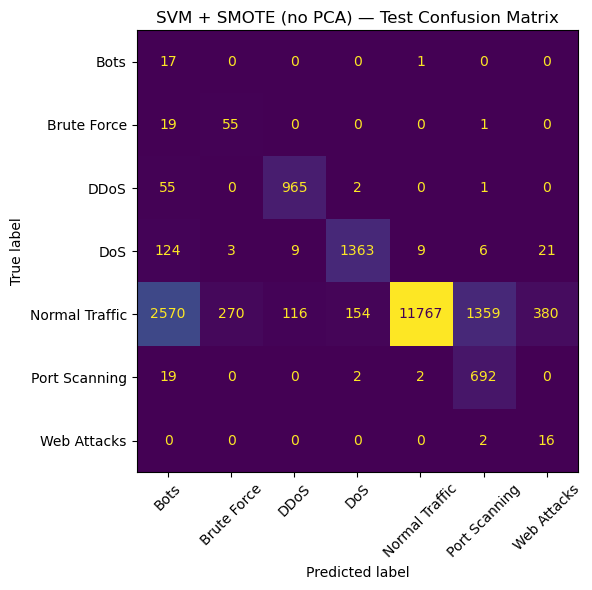

#### SMOTE in Naive Bayes
SMOTE increased the results slightly, but with or without SMOTE, Naive Bayes model performed poorly on this particular dataset. The baseline showed accuracy (≈ 17.5%) and F1-score (macro): 0.1564. With SMOTE the numbers were accuracy: 0.2799 (≈ 28.0%) and F1-score (macro): 0.2947. 

In [ ]:
nb_param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8]
}

# 3. SMOTE
all_results.append(run_experiment(
    GaussianNB(),
    nb_param_grid,
    label="NB + SMOTE",
    use_smote=True,
    use_pca=False,
    use_scaler=True
))

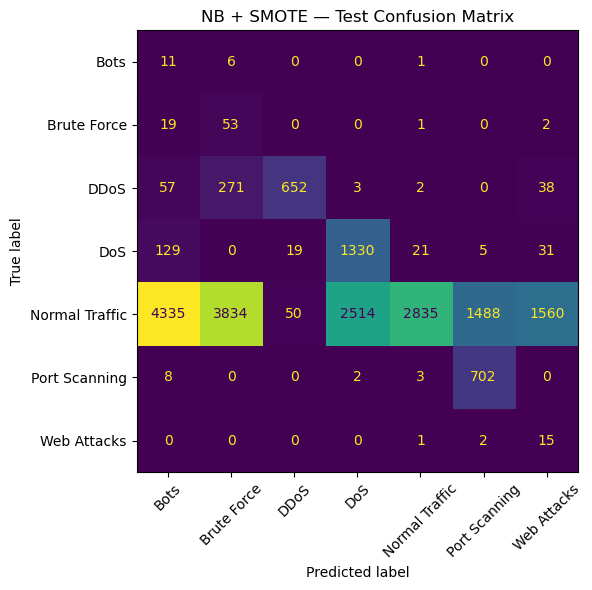

### SMOTE in decision tree models
When studying macro average F1 or macro average precision, out of all seven decision tree training models the use of SMOTE did not enhance precision or F1. On the contrary, using SMOTE created the worst classes for these metrics. This is a result of increased amount of false positives in minority classes, as with SMOTE the model is more prone to label normal traffic as attack type.

Opposite results were gained, when macro average recall was investigated. As SMOTE oversamples smaller classes, also decision tree classifies minor classes easier. At the same time, the model begins to misclassify some normal traffic samples as attacks, increasing false negatives for the majority class.

Below is a table of all runs, highlighting the use of SMOTE, and the highest score of each metric.

| Model                                      | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| DT + **no SMOTE** + no PCA + no scaler       |  **0.7941**  | **0.993**    | 0.783        | 0.811           |
| DT + **no SMOTE** + PCA + no scaler            |  0.7773      | 0.991    | 0.762        | **0.816**           |
| DT + **no SMOTE** + PCA + standard scaler      |  0.7644      | 0.989    | 0.756        | 0.775           |
| DT + **no SMOTE** + LDA + no scaler            |  0.7629      | 0.988    | 0.756        | 0.774           |
| DT + SMOTE + PCA + no scaler               |  0.7480      | 0.980    | **0.868**        | 0.707           |
| DT + SMOTE + PCA + standard scaler         |  0.7271      | 0.980    | 0.866        | 0.679           |
| DT + SMOTE + LDA + no scaler               |  0.7125      | 0.976    | 0.854        | 0.663           |

Below are the confusion matrices of comparing the SMOTE models to models without SMOTE. With no SMOTE it is clearly visible, how normal traffic is not mislabelled as minor attack types.

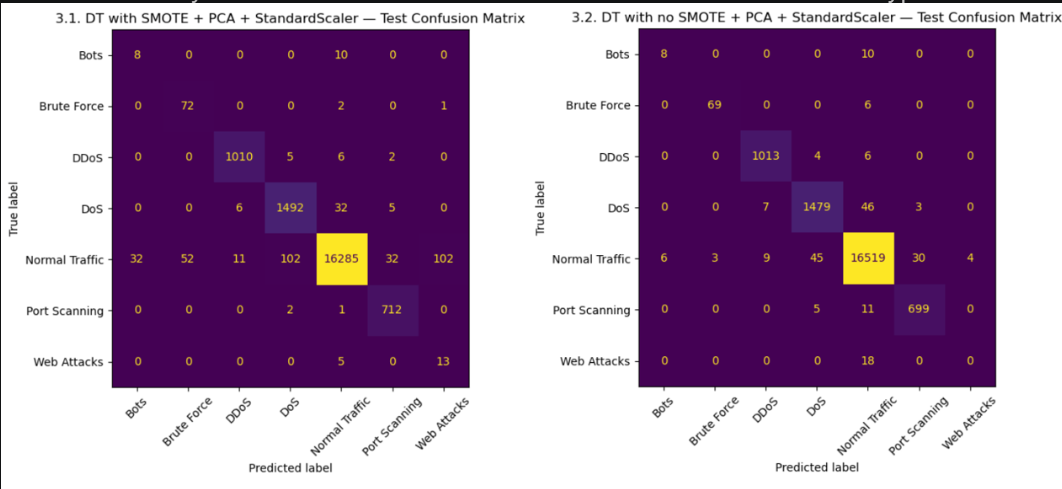

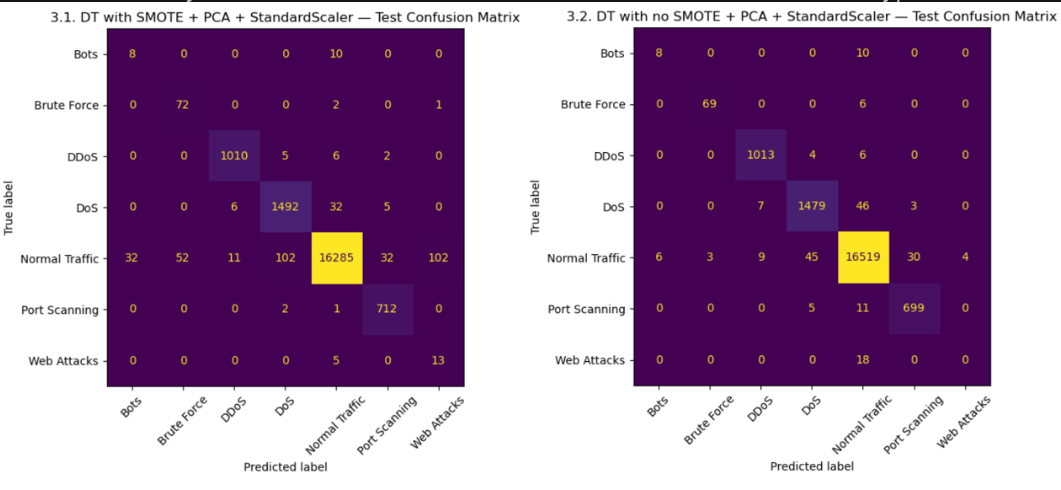

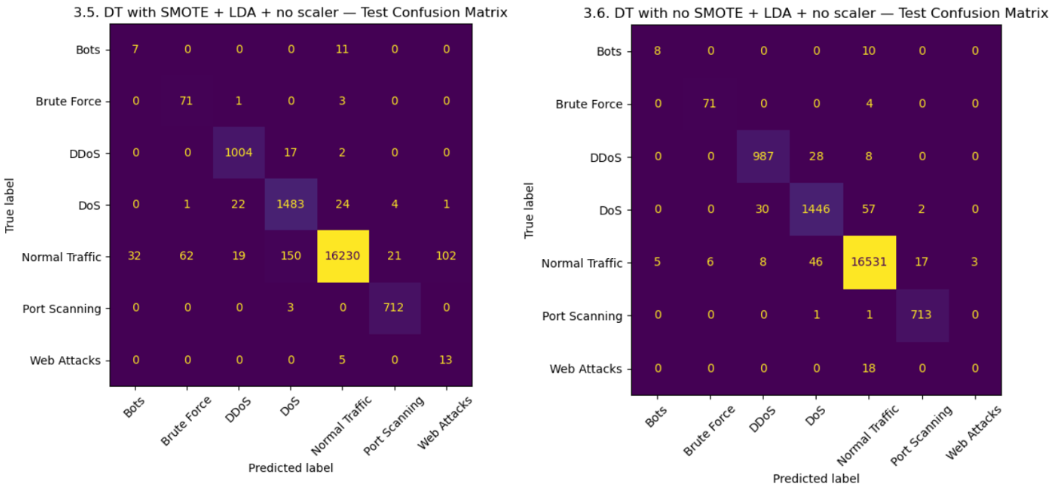

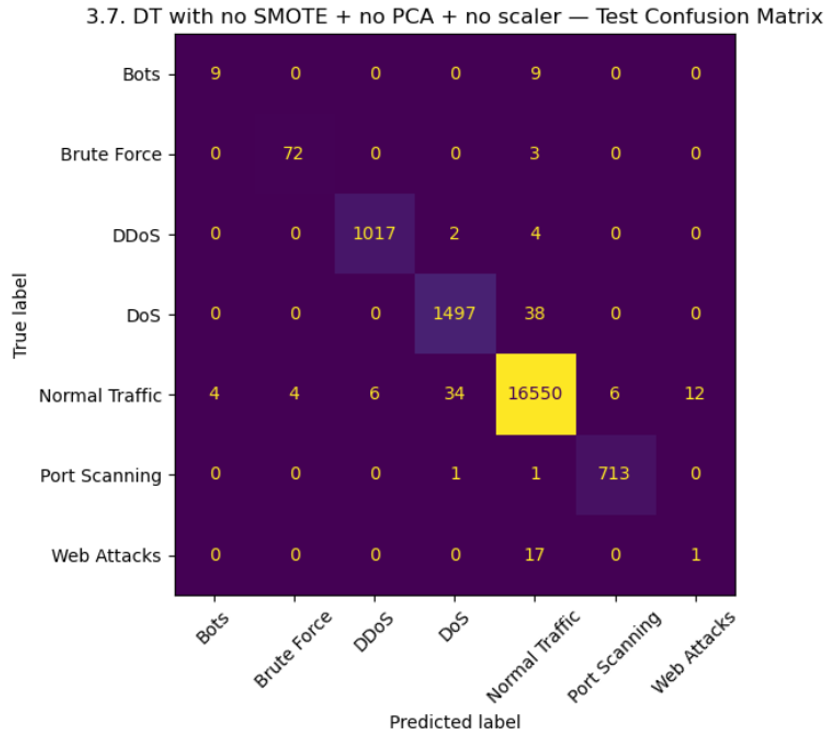

The code to run model with and without SMOTE, and with PCA and scaling:

In [ ]:
dt_grid = {
    "pca__n_components":      [4, 6, 8],
    "clf__criterion":         ["gini", "entropy"],
    "clf__max_depth":         [None, 10, 20, 30],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
    "clf__class_weight":      [None, "balanced"],
}

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42),
                   dt_grid,
                   label="3.1. DT with SMOTE + PCA + StandardScaler",
                   use_pca=True,
                   use_smote=True,
                   use_scaler=True)
)

all_results.append(
    run_experiment(DecisionTreeClassifier(random_state=42),
                   dt_grid,
                   label="3.2. DT with no SMOTE + PCA + StandardScaler",
                   use_pca=True,
                   use_smote=False,
                   use_scaler=True)
)

---

## 8. Scaling, Polyfeatures, PCA, LDA, Kernel PCA


In preprocessing, scaling is a crucial step to normalize the data into common range. It is a mandatory step for distance-based models. Without scaling the model is prone to prioritize classes with large scales. In some cases, scaling might also improve some algorithms' performance.

The default scaling method in this study is standard scaling, or standardization. In standardization, the data is transformed so, that data is centered around 0 (this is the mean value) and standard deviation is 1. Another model used as an extra training parameter is min-max scaling. This model converts the data so, that all values fall between the range of 0 and 1.

The original dataset contained dozens of features, many of which were irrelevant or redundant. Even though the amount of features was decreased to 10, there still might be features which are highly correlated. Applying dimensionality reduction can help to reduce the model complexicity while important information is still preserved.

Principal component analysis (PCA) is one of many reduction techniques. It finds the directions where variance is largest among the data points. Original features are combined into uncorrelated  principal components, containing as much variance from the data as possible. 

Similar to PCA, linear discrimination analysis (LDA) is a dimensional reduction technique in ML. Unlike PCA, which focuses on features, LDA is a supervised technique and takes classes into account. It tries to separate the classes by finding a plane/line, where distance between classes is maximised, while variance inside the class is minimized. Finally, the calculated components are directions which separate classes most. Both LDA and PCA give weighted combinations of original features.

Polyfeatures, or polynomial features, transform linear models into nonlinear dimensions. This way, linear models can capture relationships they otherwise could not. As such, polynomial features are a type of feature engineering, e.g. the creation of new input features based on the existing features.

#### SVMs and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
SVM is based on distances and therefore it is crucial to use scaling. The Standard Scaler was determined the best choice for this model.

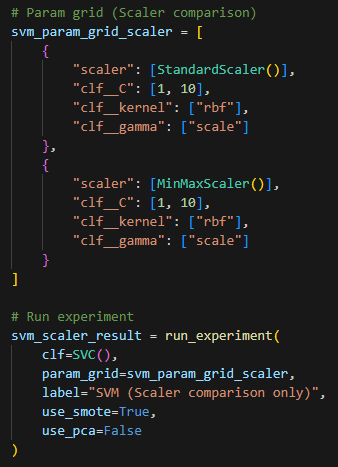

Polyfeatures and Kernel PCA were not tested with SVM, because of the RBF kernel that was used. 
Using PCA with SVM, showed no improvement on the results.
The SVM code was very time consuming and heavy on the computer (8 hours). Due to the lack of time, I was not able to perform the code with LDA.

#### Decision Tree and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
Decision tree is not distance based model, but a model which makes decisions against threshold comparison. Therefore scaling is not a mandatory or even recommended step in the pipeline. To reduce the amount of needless data trainings, standardization was used for only two models solely for testing purposes. For the same reason, min-max scaling was not introduced to decision tree models.

In theory, scaling should not change the decision tree's results. But, in the pipeline, scaling is done first, and then SMOTE and/or PCA is applied. In these cases the original training data is altered. Therefore, the way scaled models performed worse might be due to the way PCA and/or SMOTE work, not scaling itself. All in all, the use of scaling is an unneccessary step in decision trees, though results between using the scales is illustrated below.


| Models with and without SMOTE                                     | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| DT + no SMOTE + PCA + **no scaler**      |  **0.7773**      | **0.991**    | **0.762**        | **0.816**     |
| DT + no SMOTE + PCA + standard scaler      |  0.7644      | 0.989    | 0.756        | 0.775           |
| DT + SMOTE + PCA + **no scaler**           |  **0.7480**      | **0.980**    | **0.868**        | **0.707**           |
| DT + SMOTE + PCA + standard scaler         |  0.7271      | **0.980**    | 0.866        | 0.679           |

### Naive Bayes and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
The results showed that the most useful preprocessing step is to use LDA. This creates a more clear structure, even though the results are not as good as with other classification algorithms.

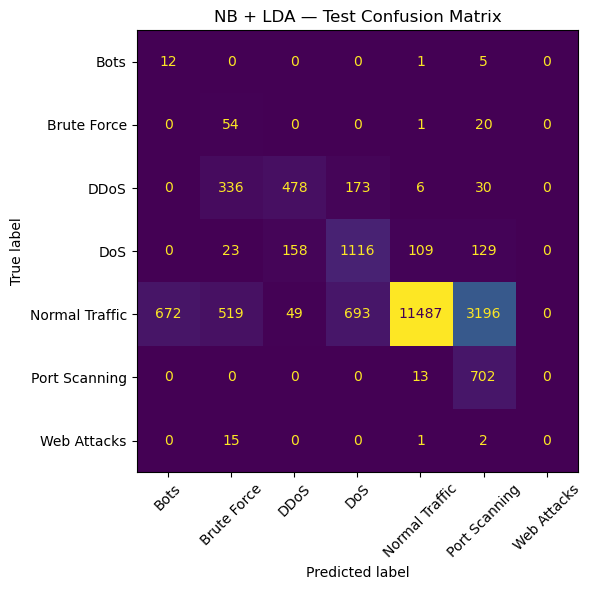

Naive Bayes did not benefit from scaling as the results are the exact same:

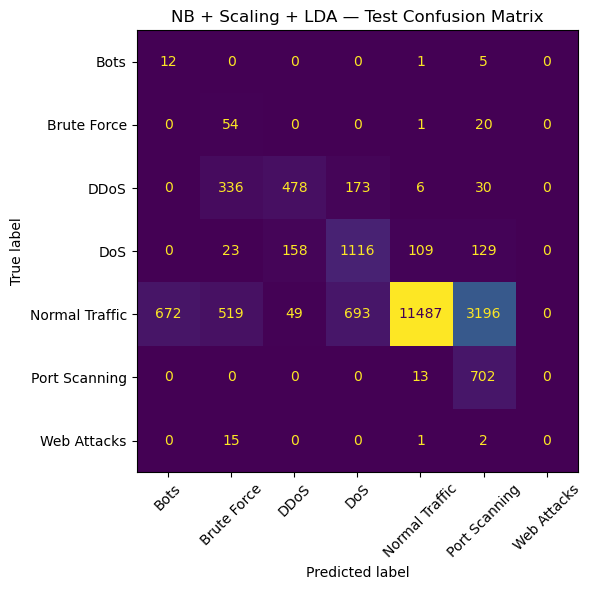

Naive Bayes is based on a "Independence" assumption which means that every feature in the dataset is independent of the others. Polynomial Features, PCA and Kernel PCA do not go well with this assumption. 


### Decision trees and Scaling, Polyfeatures, PCA, LDA, Kernel PCA
Decision tree is not distance based model, but a model which makes decisions against threshold comparison. Therefore scaling is not a mandatory or even recommended step in the pipeline. To reduce the amount of needless data trainings, standardization was used for only two models. For the same reason, min-max scaling was not introduced to decision tree models.

In theory, scaling should not change the decision tree's results. But, in the pipeline, scaling is done first, and then SMOTE and/or PCA is applied. In these cases the original training data is altered. Therefore, the way scaled models performed worse might be due to the way PCA and/or SMOTE work, not scaling itself. All in all, the use of scaling is an unneccessary step in decision trees, though results between using the scales is illustrated below.


| Models with and without SMOTE                                     | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| DT + no SMOTE + PCA + **no scaler**      |  **0.7773**      | **0.991**    | **0.762**        | **0.816**     |
| DT + no SMOTE + PCA + standard scaler      |  0.7644      | 0.989    | 0.756        | 0.775           |
| DT + SMOTE + PCA + **no scaler**           |  **0.7480**      | **0.980**    | **0.868**        | **0.707**           |
| DT + SMOTE + PCA + standard scaler         |  0.7271      | **0.980**    | 0.866        | 0.679           |

Polyfeatures were not used in decision tree models for the same reason scaling is an irrelevant preprocessing technique: Decision trees are not distance or linear based algorithms. Kernel PCA does not improve decision trees because trees already model non‑linear relationships through axis‑aligned splits, and Kernel PCA destroys the original feature structure. For this reason, Kernel PCA's were not introduced either.

But two other dimensional reduction techniques, PCA and LDA, were tested with decision trees. In GridSearchCV, models were tested with PCA components of 4, 6, and 8, and LDA with 3, 4, 6. With both dimensional reduction techniques best F1, precision, and accuracy were achieved with highest number of components.


| Model Variant                                   | Components | Test F1 | Accuracy | Macro Recall | Macro Precision |
|-------------------------------------------------|------------|---------|----------|--------------|------------------|
| DT + no SMOTE + no PCA + no scaler          | –          | **0.7941** | **0.9929** | **0.783** | 0.811 |
| DT + no SMOTE + **PCA** + no scaler                 | PCA = 8    | 0.7773 | 0.9908 | 0.762 | **0.816** |
| DT + no SMOTE + **LDA** + no scaler                 | LDA = 6    | 0.7629 | 0.9878 | 0.756 | 0.774 |
| DT + SMOTE + **PCA** + no scaler                    | PCA = 8    | 0.7480 | 0.9800 | **0.868** | 0.707 |
| DT + SMOTE + **LDA** + no scaler                    | LDA = 6    | 0.7125 | 0.9760 | 0.854 | 0.663 |



The code used in LDA is otherwise the same, but component count needs to be decreased.


Above the test table shows, how between PCA and LDA, the PCA method always resulted in best metrics. Additionally, decision tree functioned the best, if PCA was used and no other parameters (scaled, SMOTE). But, the best results were gained wihtout PCA. Below the comparison between confusion matrices of PCA and LDA illustrate, that neither managed to classify minor classes, and with LDA all of the bots were false negative:

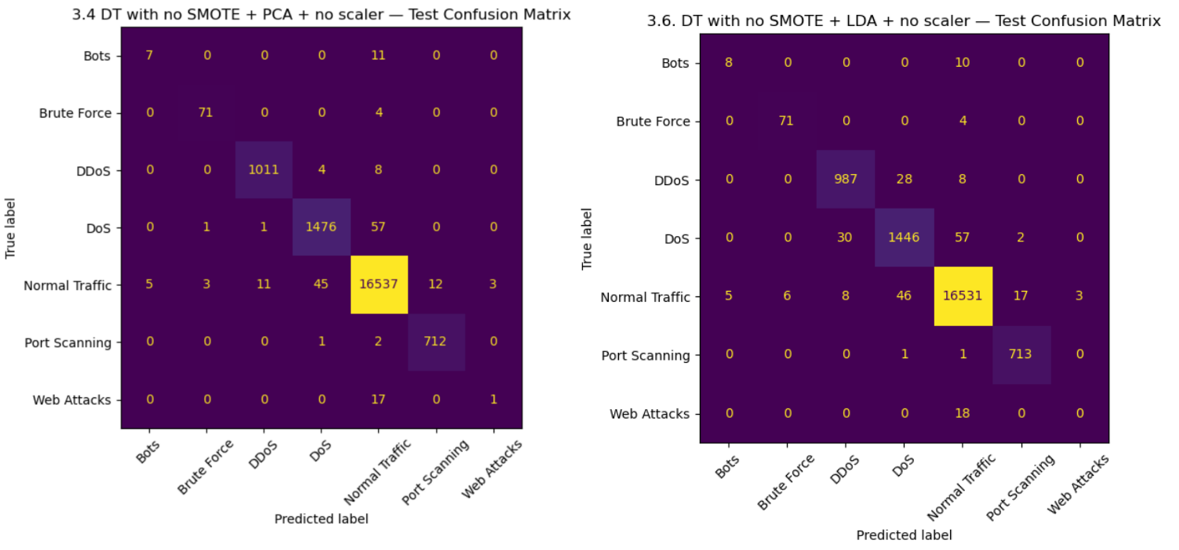

To summarize, none of these processing techniques improved algorithm's behaviour.The scaling is an unnecessary step in decision tree modelling, and with PCA/LDA the feature reduction and mixture weakens the model. As the tree picks one feature at a time, and chooses a single threshold value to split the node, with PCA/LDA, the tree loses its ability to isolate informative features, and minority class detection becomes even more difficult.

### Logistic Regression and Scaling, Polyfeatures, PCA, LDA, Kernel PCA

| Models                                     | Test F1 | Accuracy | Macro Recall | Macro Precision |
|--------------------------------------------|------------|----------|--------------|------------------|
| LR, SMOTE + PCA + no scaler      |  0.2128    | 0.146   | 0.504        | 0.293     |
| LR, SMOTE + PCA + Standard Scaler      |  0.4381      | 0.692    | 0.791        | 0.435           |
| LR + SMOTE + Standard Scaler + no PCA       | 0.4389      | 0.690    |  0.799        | 0.434           |
| LR + SMOTE + PCA + MinMaxScaler           |  0.380      | 0.654    | 0.726       | 0.383           |
| LR + SMOTE + PCA + Standard Scaler + Poly        |  0.3172      | 0.304    | 0.656        | 0.412           |
| LR + SMOTE + LDA + Standard Scaler       |  0.398      |  0.656     | 0.773       | 0.392           |

Logistic Regression calculates the weighting coefficients of features. Without scaling, accuracy was only 0.146 (14,6%) and the recall for normal traffic was only 0.038 (3,8%) which means, the model does not find the normal traffic anymore. Without scaling, the model is completely unusable.

With scaling the model was more stable and recall increased to 0.791 (79,1%) and accuracy was 0.692 (69,2%). Standard Scaler performed better than MinMaxScaler, the results are shown above in a table.

Use of PCA did not make much difference with Logistic Regression. From the results table can be seen that PCA decreased the macro f1-score approximately 0.0008. Without PCA, there was convergence warning which means the algorithm did not find the best solution with the amount of iterations given. PCA performed better than LDA and is more suitable for this data. Kernel PCA was not tested with Logistic Regression.

Polynomial Features made the model over sensitive but it did find most of the attacks and recall was at 0.656 (65,6%). However, it predicts almost all of the normal traffic as attacks and the recall for normal traffic was only 0.209 (20,9%).

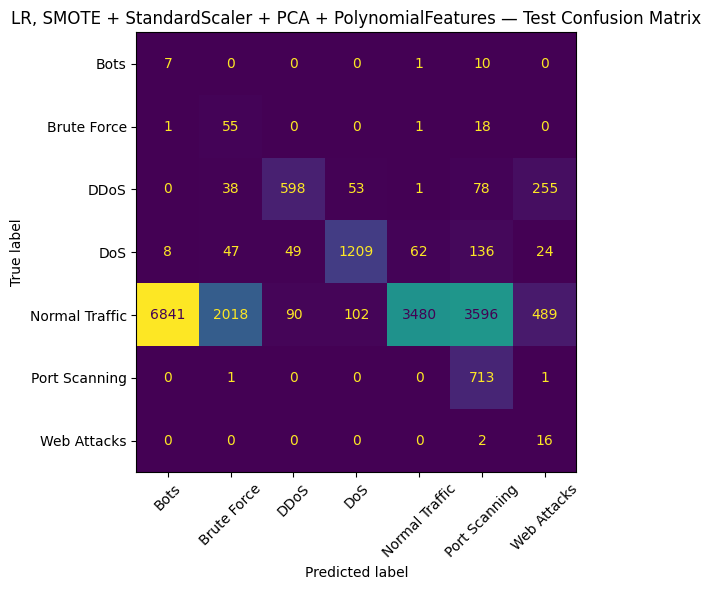

All of the codes use the same function run_experiment which allowed a controlled comparison between models, ensuring that the only difference between experiments was the specific component being tested.

Below this section there are some code snippets. The chosen parameters aim to find an optimal balance between the model's learning capacity and data compression. Since the dataset is imbalanced, the goal of the Grid Search was to ensure that the model does not underperform due to overly strict regularization or lose critical information as a result of excessive PCA dimensionality reduction.

In [ ]:
# Parameters without PCA
lr_params_no_pca = {
    'clf__C': [1.0, 10.0, 50.0, 100.0]
}

# Parameters with PCA
lr_params = {
    'clf__C': [10.0, 50.0, 100.0],
    'pca__n_components': [4, 6, 8, 10]
}

# LR with SMOTE, StandardScaler, no PCA
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params_no_pca, "LR, SMOTE + StandardScaler, no PCA",
    use_pca=False))

# Model using Polynomial Features with SMOTE, StandardScaler and PCA
all_results.append(run_experiment(
    LogisticRegression(max_iter=2000, solver='lbfgs', random_state=42), 
    lr_params, "LR, SMOTE + StandardScaler + PCA + PolynomialFeatures",
    use_smote=True,
    use_scaler=True,
    use_pca=True,
    use_poly=True))


---

## 9. Training setups

#### Hyperparameters in SVMs

The following hyperparameters were tested after a few tests:

| Hyperparameter | Values tested |
|----------------|---------------|
| C              | 0.1, 1, 10    |
| kernel         | rbf           |
| gamma          | scale, auto   |
| PCA components | 5, 8 (when PCA applied) |

The regularization parameter C was tested with three different values. Smaller values can cause underfitting, when bigger values can result in overfitting. The results after the experiments showed that C = 1 provided the best balance when SMOTE was used. C = 10 worked better when using PCA, but PCA did not provide any improvement to the model.

The RBF kernel was used in all experiments to capture non-linear relationships in the dataset. It allowed flexibility to decision boundaries.

The gamma determines how far a single training examples influence reaches. The results showed that it was quite 50/50, but the best model SVM + SMOTE performed better with gamma = scale.

As mentioned previously, using PCA showed negative or neutral impact on the performance of the model. It is most likely that it removed important class-separating information, even though it can be useful to other algorithms to reduce noise.

SVM proved to be computationally extremely time consuming in this assignment. Training time was significantly higher compared to other algorithms, mainly due to the use of the RBF kernel and GridSearchCV, which depends on distance-based kernel computations between data points and testing all the combinations. This increases computational complexity, especially for larger datasets. Changes to the hyperparameters and their values did not lead to significant improvements in either training time or model performance. Due to the project deadline, a more extensive evaluation of alternative methods was not feasible. A small research suggests that the RandomizedSearchCV could have been less time consuming.

#### Hyperparameters in Naive Bayes

The following hyperparameters were tested after a few tests:
| Hyperparameter | Values tested |
|----------------|---------------|
| var smoothing  | 1e-9, 1e-8, 1e-7 |
| PCA components | 5, 8, 10 (when PCA applied) |

Naive Bayes is based strongly on the "Independence" assumption and only a few hyperparameters are useful. The var_smoothing stabilizes the variance calculations. This is done by adding a small value to the variance of each feature. The tested values were 1e-9, 1e-8 and 1e-7. The Naive Bayes results were showed that is not the best classification model to use with this data, due to the strong assumptions. The best var_smoothing values varied between 1e-9 and 1e-8.

Naive Bayes performed poorly on this dataset mainly due to failures to satisfy its core assumptions. The characteristics in this kind of data are highly correlated and the data is also severly imbalanced. Therefore Naive Bayes is not the best choice.

#### Hyperparameters in Decision Tree

SMOTE, scaling, and dimensional reducing techniques were handled in previous sections, but in addition to those, decision tree can be also modified with hyperparameters.

Couple of test runs were done first, and finally following hyperparemeters were added:

| Hyperparameter         | Values tested                     |
|------------------------|------------------------------------|
| criterion       | gini, entropy                      |
| max depth       | None, 10, 20, 30                   |
| min samples split | 2, 5, 10                         |
| min sample leaf  | 1, 2, 4                          |
| class weight    | None, balanced                     |

Out of impurity metrics, Gini impurity and entropy were used in pipeline. While both help to determine how mixed or pure a dataset is, entropy focuses more on minor classes: it requires the node to be purer. So if the node contains attack classes, node's impurity is also higher with entropy than with gini. The results also support the use of entropy as in most cases, entropy was used and also the best model (DT + no PCA + no scaler) preferred entropy.

Maximum depth of the decision tree defines, how many layers of nodes there can be. Fewer layers may result in underfitted data, then again larger or even infinite amount of nodes might capture the noise in the dataset. The best model functioned best without depth restrain, though so did the worst models. Most likely use of PCA, scaling, and LDA fine tuned the samples so, that the higher amount of layers (more than 20) would cause overfitting and decrease in e.g. precision. With SMOTE, best models always used max depth of none. This is a result of increase in synthetic points, and most likely noise in the dataset. A higher amount of nodes helps to fit these datapoints.

Minimum samples split determines the minimum amount of datapoints that must be contained in a node before it can be split. To control the amount of samples in a terminal leaf node, a hyperparameter minimum samples leaf is defined. Combining these parameters in GridSearchCV resulted always in the same parameter choosing: Node should be split if there are 2 or 5 samples, and the minimum quantity of samples per leaf should not be restricted. 2 is needed to handle the noisy synthetic samples created by SMOTE, while 5 prevents overfitting on the imbalanced original dataset without preventing the tree from isolating rare classes.

Another hyperparameter dominating the model optimization was unbalanced class weight. Class balancing means, that before training there are sampled an equal number of samples from each class. Despite the fact that balancing should improve minor class detection, class weight="balanced" was never selected. When SMOTE was used, it already balanced the training data when applied, and in the non‑SMOTE models the decision tree handled imbalance better without class weighting. And if balancing happens after the train–test split, the classifier never sees the original imbalance.

Below is the summary of hyperparameters and their effect on macro F1.

| Model Variant (with Test F1)                     | SMOTE | Class Balance | Dim. Red. | Components | Scaler | Criterion | Max Depth | Min Samples Split | Min Samples Leaf |
|--------------------------------------------------|-------|----------------|-----------|------------|--------|-----------|-----------|--------------------|-------------------|
| **DT + no PCA + no scaler (F1 = 0.7941)**        | No    | Imbalanced     | None      | –          | None   | Entropy   | None      | 5                  | 1                 |
| **DT + PCA + no scaler (F1 = 0.7773)**           | No    | Imbalanced     | PCA       | 8          | None   | Entropy   | 20        | 5                  | 1                 |
| **DT + PCA + StandardScaler (F1 = 0.7644)**      | No    | Imbalanced     | PCA       | 6          | Std    | Entropy   | 20        | 2                  | 1                 |
| **DT + LDA + no scaler (F1 = 0.7629)**           | No    | Imbalanced     | LDA       | 6          | None   | Entropy   | 20        | 5                  | 1                 |
| **DT + SMOTE + PCA + no scaler (F1 = 0.7480)**   | Yes   | Imbalanced       | PCA       | 8          | None   | Entropy   | None      | 2                  | 1                 |
| **DT + SMOTE + PCA + StdScaler (F1 = 0.7271)**   | Yes   | Imbalanced       | PCA       | 8          | Std    | Gini      | None      | 5                  | 1                 |
| **DT + SMOTE + LDA + no scaler (F1 = 0.7125)**   | Yes   | Imbalanced       | LDA       | 6          | None   | Entropy   | None      | 2                  | 1                 |


---

## 10. Classification Results and Best model/models


---

### Combined model comparison (accuracy, F1, precision, recall)

| Model Variant | Preprocessing | Accuracy | F1-score | Macro precision | Macro recall |
|---------------|---------------|----------|----------|------------------|--------------|
| Decision Tree (best model) | No SMOTE, No PCA, No Scaler | 0.9929 | 0.7941 | 0.8110 | 0.7830 |
| SVM | Baseline | 0.9281 | 0.3930 | 0.488 | 0.362 |
| SVM | PCA | 0.9271 | 0.3919 | 0.558 | 0.361 |
| SVM (best model) | SMOTE | 0.7438 | 0.4988 | 0.475 | 0.868 |
| SVM | SMOTE + PCA | 0.7431 | 0.4939 | 0.470 | 0.868 |
| SVM | Scaler comparison (StdScaler best) | 0.7438 | 0.4988 | 0.475 | 0.868 |
| Naive Bayes | Baseline | 0.1746 | 0.1564 | 0.237 | 0.437 |
| Naive Bayes | Standard Scaler | 0.2944 | 0.2755 | 0.352 | 0.509 |
| Naive Bayes | SMOTE | 0.2799 | 0.2947 | 0.369 | 0.687 |
| Naive Bayes | PCA | 0.5991 | 0.3180 | 0.306 | 0.561 |
| Naive Bayes (best model) | LDA | 0.6925 | 0.3486 | 0.357 | 0.608 |
| Naive Bayes | Polynomial Features | 0.1603 | 0.1854 | 0.307 | 0.407 |
| Naive Bayes | StdScaler + LDA | 0.6925 | 0.3486 | 0.357 | 0.608 |
| Naive Bayes | StdScaler + LDA + SMOTE | 0.2964 | 0.2060 | 0.254 | 0.457 |
| Naive Bayes | StdScaler + PCA + SMOTE | 0.1700 | 0.1691 | 0.250 | 0.445 |


Best decision tree model confusion matrix:

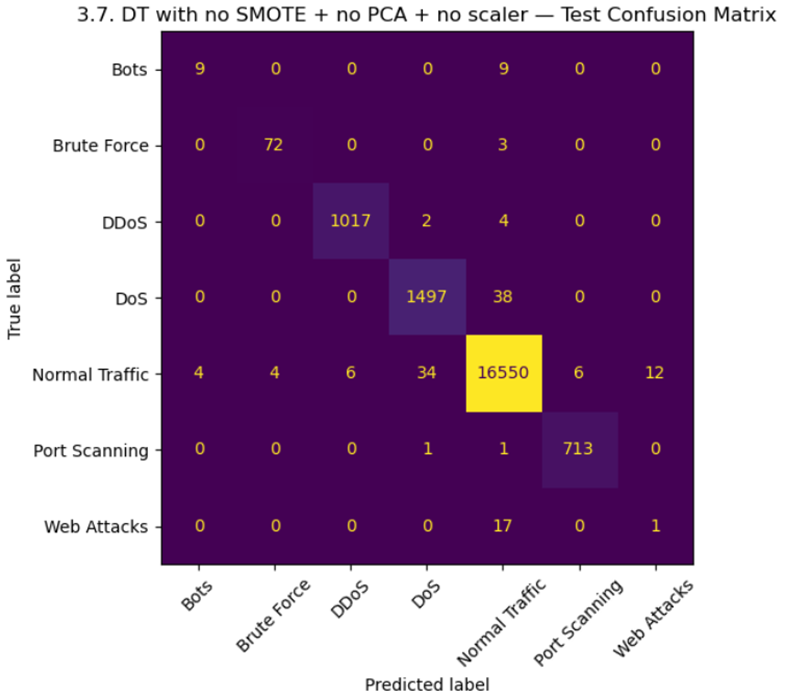

Finally, make sure for the last time that this documentation of yours would make sense for somebody who might continue your work with extended data later on.
